Task 03: Forest Cover Type Classification

Problem Statement: The objective of this task is to build a multi-class classification model to predict the type of forest cover based on cartographic and environmental features.

In [1]:
import pandas as pd

df = pd.read_csv("covtype.csv")

print("Shape:", df.shape)
df.head()

Shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [2]:
df.info()
df.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null  int64
 12 

np.int64(0)

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nColumns:\n", df.columns)

Shape: (581012, 55)

Missing values:
 0

Columns:
 Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37'

In [4]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (581012, 54)
y shape: (581012,)


In [5]:
df_sample = df.sample(n=100000, random_state=42)

X = df_sample.drop("Cover_Type", axis=1)
y = df_sample["Cover_Type"]

print(X.shape)

(100000, 54)


In [6]:
print("Unique classes:", sorted(df["Cover_Type"].unique()))
print("Number of classes:", df["Cover_Type"].nunique())

Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Number of classes: 7


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (80000, 54)
Testing size: (20000, 54)


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
y_pred = rf_model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9035

Classification Report:

              precision    recall  f1-score   support

           1       0.91      0.88      0.90      7333
           2       0.90      0.94      0.92      9732
           3       0.88      0.93      0.90      1229
           4       0.91      0.70      0.79        89
           5       0.91      0.54      0.68       339
           6       0.88      0.77      0.82       589
           7       0.96      0.85      0.90       689

    accuracy                           0.90     20000
   macro avg       0.91      0.80      0.84     20000
weighted avg       0.90      0.90      0.90     20000



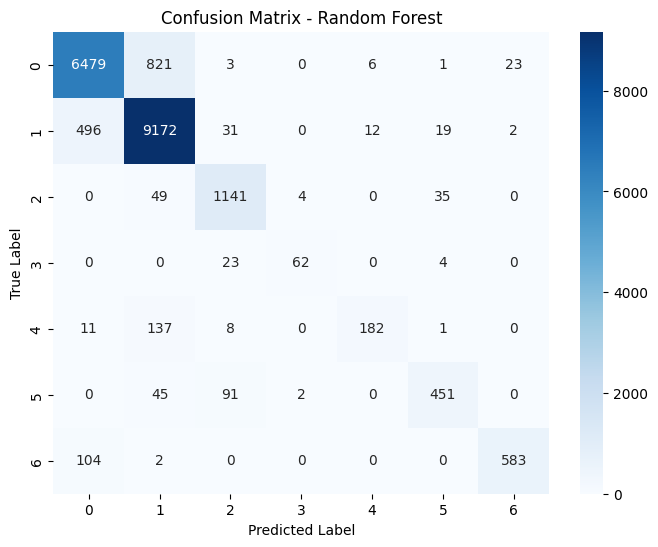

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [12]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
0,Elevation,0.236613
5,Horizontal_Distance_To_Roadways,0.104527
9,Horizontal_Distance_To_Fire_Points,0.097951
3,Horizontal_Distance_To_Hydrology,0.060726
4,Vertical_Distance_To_Hydrology,0.057710
1,Aspect,0.054215
7,Hillshade_Noon,0.050400
8,Hillshade_3pm,0.048872
6,Hillshade_9am,0.048396
2,Slope,0.039753


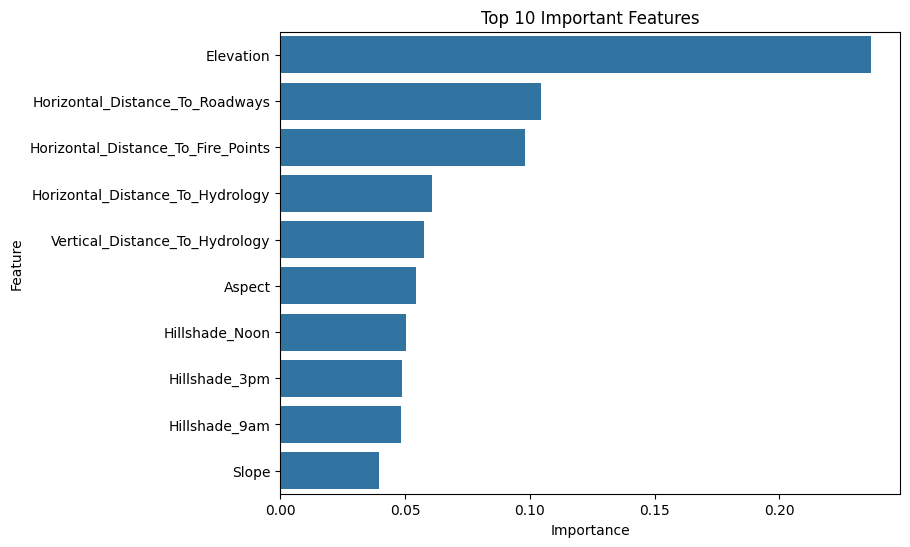

In [13]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

In [17]:
y = df_sample["Cover_Type"] - 1   # converts 1..7 -> 0..6
X = df_sample.drop("Cover_Type", axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      7333
           1       0.84      0.88      0.86      9732
           2       0.86      0.91      0.88      1229
           3       0.91      0.78      0.84        89
           4       0.90      0.47      0.62       339
           5       0.83      0.72      0.77       589
           6       0.91      0.83      0.87       689

    accuracy                           0.84     20000
   macro avg       0.87      0.77      0.81     20000
weighted avg       0.84      0.84      0.84     20000



In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

# 1) SAMPLE (50,000 rows) to make tuning fast + stable
df_sample_small = df.sample(n=50000, random_state=42)

X_small = df_sample_small.drop("Cover_Type", axis=1)
y_small = df_sample_small["Cover_Type"] - 1


# 2) TRAIN-TEST SPLIT (stratify keeps class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

In [46]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", sorted(y_train.unique()))

Train shape: (40000, 54)
Test shape: (10000, 54)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [47]:
# 3) PARAMETER SEARCH SPACE (what values to try)
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# 4) BASE XGBOOST MODEL (RandomizedSearch will tune params)
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

# 5) RANDOMIZED SEARCH (faster than GridSearch)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=5,
    scoring="accuracy",
    cv=2,
    verbose=2,
    random_state=42
)

# Run tuning
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=8, n_estimators=400, subsample=0.7; total time=   8.2s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=8, n_estimators=400, subsample=0.7; total time=   8.3s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=400, subsample=0.7; total time=   5.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, n_estimators=400, subsample=0.7; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=6, n_estimators=400, subsample=1.0; total time=   6.2s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=6, n_estimators=400, subsample=1.0; total time=   6.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=6, n_estimators=400, subsample=0.8; total time=   6.6s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=6, n_estimators=400, subsample=0.8; total time=   7.0s
[CV] END colsamp

In [48]:
# 6) TEST PERFORMANCE of the BEST model found
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_best)
print("\nTuned XGBoost Test Accuracy:", test_acc)

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_best))


Tuned XGBoost Test Accuracy: 0.8953

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      3680
           1       0.90      0.93      0.91      4860
           2       0.85      0.90      0.88       617
           3       0.86      0.68      0.76        44
           4       0.87      0.52      0.65       159
           5       0.83      0.75      0.78       293
           6       0.93      0.87      0.90       347

    accuracy                           0.90     10000
   macro avg       0.88      0.79      0.82     10000
weighted avg       0.90      0.90      0.89     10000



In [49]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost (Default)", "XGBoost (Tuned)"],
    "Accuracy": [0.9035, 0.84, 0.8953]
})

comparison_df

,Model,Accuracy
0,Random Forest,0.9035
1,XGBoost (Default),0.8400
2,XGBoost (Tuned),0.8953


After hyperparameter tuning, XGBoost accuracy improved significantly from 84% to 89.53%. Although Random Forest slightly outperformed XGBoost at 90.35%, both models demonstrated strong predictive performance on the dataset. This suggests that tree-based ensemble methods are highly effective for the Forest Cover Type classification problem.